# Agricultural Employment vs Inflation

This notebook analyzes the relationship: when **Employment in Agriculture (% of total employment)** shifts, does it correlate with spikes or drops in **Inflation (Consumer Prices %)**?

This answers the macroeconomic question: does reducing the agricultural workforce correlate with food scarcity or higher consumer prices?

## 1. Data Loading & Initial Exploration

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set directory context for relative paths if needed
if os.path.basename(os.getcwd()) == 'Data_Analysis':
    os.chdir('..')

plt.style.use('default')

# Load Inflation Data
inflation_df = pd.read_csv('economy/Inflation, consumer prices for Sri Lanka.csv')
inflation_df.rename(columns={'observation_date': 'Year', 'FPCPITOTLZGLKA': 'Inflation_%'}, inplace=True)
inflation_df['Year'] = pd.to_datetime(inflation_df['Year']).dt.year
inflation_df.set_index('Year', inplace=True)

print("Inflation Data Info:")
print(inflation_df.info())
inflation_df.head()

Inflation Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 65 entries, 1960 to 2024
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Inflation_%  65 non-null     float64
dtypes: float64(1)
memory usage: 780.0 bytes
None


,Inflation_%
Year,
1960,-1.544677
1961,1.134444
1962,1.503580
1963,2.272905
1964,3.195647


In [2]:
# Load Agricultural Employment Data
agri_path = 'labour/finalized_csv/Employment_by_sector_(%)_sl_indicators/Employment in agriculture (% of total employment) (modeled ILO estimate).csv'
agri_df = pd.read_csv(agri_path)
agri_df = agri_df[['Year', 'Value']].copy()
agri_df.rename(columns={'Value': 'Agriculture_Employment_%'}, inplace=True)
agri_df['Year'] = agri_df['Year'].astype(int)
agri_df.set_index('Year', inplace=True)

print("Agriculture Employment Data Info:")
print(agri_df.info())
agri_df.head()

Agriculture Employment Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 35 entries, 2025 to 1991
Data columns (total 1 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Agriculture_Employment_%  35 non-null     float64
dtypes: float64(1)
memory usage: 560.0 bytes
None


,Agriculture_Employment_%
Year,
2025,25.857
2024,26.317
2023,26.456
2022,26.493
2021,27.276


## 2. Missing Values Analysis & Imputation

In [3]:
# Fill any missing values with linear interpolation
inflation_clean = inflation_df.interpolate(method='linear').dropna()
agri_clean = agri_df.interpolate(method='linear').dropna()

print("Preprocessing done.")

Preprocessing done.


## 3. Data Alignment and Merging

In [4]:
# Inner join to guarantee alignment across time
combined_df = inflation_clean.join(agri_clean, how='inner')

print(f"Combined Dataset: {len(combined_df)} records (from {combined_df.index.min()} to {combined_df.index.max()})")
combined_df.head()

Combined Dataset: 34 records (from 1991 to 2024)


,Inflation_%,Agriculture_Employment_%
Year,,
1991,12.185631,39.000
1992,11.383437,40.477
1993,11.746737,36.210
1994,8.448712,39.033
1995,7.674849,35.312


## 4. Comprehensive Correlation Analysis

In [5]:
y_vals = combined_df['Inflation_%'].values
x_vals = combined_df['Agriculture_Employment_%'].values

pearson_r, pearson_p = stats.pearsonr(x_vals, y_vals)
spearman_r, spearman_p = stats.spearmanr(x_vals, y_vals)

print("=" * 60)
print("CORRELATION: Agricultural Employment vs Inflation")
print("=" * 60)
print(f"Pearson (Linear):       r = {pearson_r:.4f}  | p-value = {pearson_p:.6f}")
print(f"Spearman (Monotonic):   Rho = {spearman_r:.4f} | p-value = {spearman_p:.6f}")
print("=" * 60)


CORRELATION: Agricultural Employment vs Inflation
Pearson (Linear):       r = 0.0069  | p-value = 0.969317
Spearman (Monotonic):   Rho = 0.3617 | p-value = 0.035587


## 5. Extensive Visualization

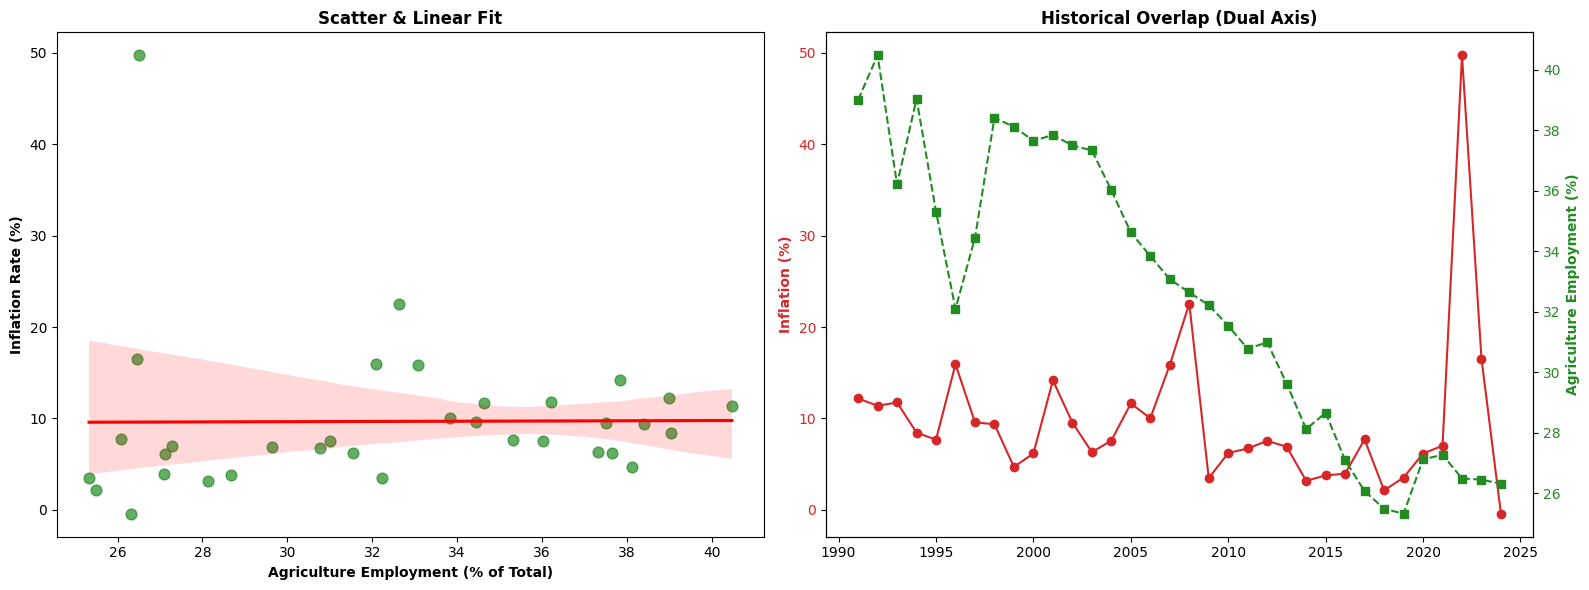

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Scatter with Regression Line
sns.regplot(x=x_vals, y=y_vals, ax=axes[0], scatter_kws={'alpha': 0.7, 's': 60, 'color': 'forestgreen'}, line_kws={'color': 'red'})
axes[0].set_xlabel('Agriculture Employment (% of Total)', fontweight='bold')
axes[0].set_ylabel('Inflation Rate (%)', fontweight='bold')
axes[0].set_title('Scatter & Linear Fit', fontweight='bold')

# 2. Time Series Dynamics
ax_time = axes[1]
ax_time.plot(combined_df.index, combined_df['Inflation_%'], color='tab:red', marker='o', label='Inflation (%)')
ax_time.set_ylabel('Inflation (%)', color='tab:red', fontweight='bold')
ax_time.tick_params(axis='y', labelcolor='tab:red')
ax_twin = ax_time.twinx()
ax_twin.plot(combined_df.index, combined_df['Agriculture_Employment_%'], color='forestgreen', marker='s', linestyle='--', label='Agri Employment (%)')
ax_twin.set_ylabel('Agriculture Employment (%)', color='forestgreen', fontweight='bold')
ax_twin.tick_params(axis='y', labelcolor='forestgreen')
ax_time.set_title('Historical Overlap (Dual Axis)', fontweight='bold')

plt.tight_layout()
plt.show()